In [1]:
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt

from h5 import HDFArchive
import coqui

Hartree_eV = 27.211386245988

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin065 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


Starting serial run at: 2026-05-22 21:19:36.357554


## Ab Initio GW+EDMFT for Quantum Materials

<figure style="text-align: center;">
 <img src="../../images/gw_edmft_hilbert_space.png" alt="Hilbert space partitioning in GW+EDMFT" width="50%">
 <figcaption><em>Figure&nbsp;1:</em> Hilbert-space partitioning in GW+EDMFT. The full single-particle space $\mathcal{B}$ is treated at the GW level, while a low-energy correlated subspace $\mathcal{C}$ is treated nonperturbatively with EDMFT. A double-counting term removes the contribution that GW already includes on $\mathcal{C}$.</figcaption>
</figure>

This tutorial introduces the ab initio GW+EDMFT workflow in CoQuí using cubic SrVO$_3$ as an example.

**Why go beyond GW?** As we saw in Tutorial 02, GW is a perturbative theory built around the random phase approximation. It works well for weakly to moderately correlated materials, but it breaks down when local correlations dominate the low-energy physics — Mott insulators, materials with strong Hund's coupling, and the lower Hubbard band / satellite features of correlated metals all sit outside its reach. SrVO$_3$ is a canonical example: its three $t_{2g}$ orbitals near the Fermi level carry strong local correlations that produce a lower Hubbard band and a renormalized quasiparticle peak, neither of which GW alone can capture.

**Quantum embedding as the remedy.** The idea of quantum embedding is to split the Hilbert space into two parts and treat each at the level of theory it requires: a large environment $\mathcal{B}\backslash\mathcal{C}$ in which weak, nonlocal correlations dominate, and a small correlated subspace $\mathcal{C}$ in which local, nonperturbative correlations must be handled exactly. In GW+EDMFT, $\mathcal{B}$ is treated with GW and $\mathcal{C}$ is treated with extended dynamical mean-field theory (EDMFT), which extends DMFT to include a dynamic local interaction $\mathcal{U}(i\Omega_n)$ in addition to the local hybridization encoded in the Weiss field $\mathcal{G}(i\omega_n)$.

This decomposition is made rigorous by the Almbladh free-energy functional, which expresses the total free energy of the system as

$$
\Psi[G,W] \approx \Psi^{\mathrm{GW+EDMFT}}[G,W] = \Psi^{\mathrm{GW}}_{\mathcal{B}}[G,W] + \Psi^{\mathrm{EDMFT}}_{\mathcal{C}}[G,W] - \Psi^{\mathrm{DC}}_{\mathcal{C}}[G,W]. 
$$

Here, $\Psi^{\mathrm{GW}}_{\mathcal{B}}$ is the GW free energy evaluated on the full space, $\Psi^{\mathrm{EDMFT}}_{\mathcal{C}}$ adds the local EDMFT correction restricted to $\mathcal{C}$, and $\Psi^{\mathrm{DC}}_{\mathcal{C}}$ subtracts the part that GW has already accounted for inside $\mathcal{C}$ so that no diagram is counted twice.

**Self-consistency equations.** Stationarity of $\Psi$ with respect to $G$ and $W$ yields the GW+EDMFT self-consistency equations that we iterate in this tutorial. The lattice self-energy and polarization follow from the functional derivatives $\Sigma=\delta\Psi/\delta G$ and $\Pi=-2\,\delta\Psi/\delta W$, which inside the Almbladh decomposition take the form

$$
\begin{aligned}
\Sigma^{\mathbf{k}} &= \Sigma_{\mathrm{GW}}^{\mathbf{k}} + C^{\mathbf{k}\dagger} \left[\, \tilde{\Sigma}_{\mathrm{imp}} - \tilde{\Sigma}_{\mathrm{DC}} \,\right] C^{\mathbf{k}}, \\
\Pi^{\mathbf{q}}    &= \Pi_{\mathrm{GW}}^{\mathbf{q}}    + B^{\mathbf{q}\dagger}\left[\, \tilde{\Pi}_{\mathrm{imp}}    - \tilde{\Pi}_{\mathrm{DC}}    \,\right] B^{\mathbf{q}}.
\end{aligned}
$$

Here $C^{\mathbf{k}}$ and $B^{\mathbf{q}}$ are the fermionic and bosonic projectors that map one- and two-particle quantities from the full space $\mathcal{B}$ onto the correlated subspace $\mathcal{C}$, and tildes denote quantities defined inside $\mathcal{C}$. In CoQuí, $C^{\mathbf{k}}$ is the MLWF projector and $B^{\mathbf{q}}$ is its two-particle counterpart for the bosonic (polarization / screened-interaction) channel.

The lattice GW contributions $\Sigma_{\mathrm{GW}}^{\mathbf{k}}$ and $\Pi_{\mathrm{GW}}^{\mathbf{q}}$ are evaluated on the full Hilbert space $\mathcal{B}$ using the cubic-scaling THC/ISDF algorithm of [arXiv:2401.12308](https://arxiv.org/pdf/2401.12308) (see Tutorial 02). The double-counting terms

$$
\tilde{\Sigma}_{\mathrm{DC}} = \tilde{G}_{\mathrm{loc}}\,\tilde{W}_{\mathrm{loc}}, \qquad
\tilde{\Pi}_{\mathrm{DC}}    = -\tilde{G}_{\mathrm{loc}}\,\tilde{G}_{\mathrm{loc}},
$$

represent the same GW diagrams evaluated using the *locally projected* propagators

$$
\tilde{G}_{\mathrm{loc}} = \textstyle\sum_{\mathbf{k}} C^{\mathbf{k}}\, G^{\mathbf{k}}\, C^{\mathbf{k}\dagger}, \qquad
\tilde{W}_{\mathrm{loc}} = \textstyle\sum_{\mathbf{q}} B^{\mathbf{q}}\, W^{\mathbf{q}}\, B^{\mathbf{q}\dagger},
$$

so that the bracketed corrections in the master equations above isolate the *beyond-GW* impurity contribution to the lattice self-energy and polarization.

The impurity self-energy $\tilde{\Sigma}_{\mathrm{imp}}$ and polarization $\tilde{\Pi}_{\mathrm{imp}}$ are obtained by solving an EDMFT impurity action

$$
\begin{split}
 \mathcal{S} &= \iint_0^{\beta} d\tau\, d\tau' \sum_{a,b} c^{\dagger}_{a}(\tau)\,\tilde{\mathcal{G}}^{-1}_{ab}(\tau-\tau')\,c_{b}(\tau') \\
 &+ \frac{1}{2}\iint_0^{\beta} d\tau\, d\tau' \sum_{a,b,c,d} \tilde{\mathcal{U}}_{abcd}(\tau-\tau')\, c^{\dagger}_{a}(\tau)\, c^{\dagger}_{c}(\tau')\, c_{d}(\tau')\, c_{b}(\tau),
\end{split}
$$

in which the fermionic and bosonic Weiss fields are related to the local propagators by the impurity Dyson equations

$$
\tilde{\mathcal{G}}^{-1}(i\omega_{n}) = \tilde{G}_{\mathrm{loc}}^{-1}(i\omega_{n}) + \tilde{\Sigma}_{\mathrm{imp}}(i\omega_{n}), \qquad
\tilde{\mathcal{U}}^{-1}(i\Omega_{n}) = \tilde{W}_{\mathrm{loc}}^{-1}(i\Omega_{n}) + \tilde{\Pi}_{\mathrm{imp}}(i\Omega_{n}).
$$

The action is then solved with a numerically exact continuous-time quantum Monte Carlo (CT-QMC) solver.

The EDMFT corrections $[\tilde{\Sigma}_{\mathrm{imp}} - \tilde{\Sigma}_{\mathrm{DC}}]$ and $[\tilde{\Pi}_{\mathrm{imp}} - \tilde{\Pi}_{\mathrm{DC}}]$ are then upfolded back to $\mathcal{B}$ through the projectors, after which the lattice $G^{\mathbf{k}}$ and $W^{\mathbf{q}}$ are updated through their Dyson equations 

$$
\begin{aligned}
&G^{\mathbf{k}}(i\omega_{n}) = \left[ G^{\mathbf{k},-1}_{0}(i\omega_{n}) - \Sigma^{\mathbf{k}}(i\omega_{n})\right]^{-1}\\
&W^{\mathbf{q}}(i\Omega_{n}) = \left[ V^{\mathbf{q},-1} - \Pi^{\mathbf{q}}(i\Omega_{n})\right]^{-1},
\end{aligned}
$$

which completes one iteration of the GW+EDMFT loop. 

A new iteration is started using the updated lattice propagators to compute a new GW self-energy and polarization as well as the EDMFT corrections. The procedure is iterated until 

$$
\tilde{G}_{\mathrm{loc}} = \tilde{G}_{\mathrm{imp}}, \qquad
\tilde{W}_{\mathrm{loc}} = \tilde{W}_{\mathrm{imp}}.
$$

### Section 1: Ab initio GW+EDMFT in CoQui

<figure style="text-align: center;">
 <img src="../../images/gw_edmft_cartoon.png" alt="Self-consistent GW+EDMFT workflow" width="80%">
 <figcaption><em>Figure&nbsp;2:</em> Self-consistent GW+EDMFT workflow in CoQui.</figcaption>
</figure>

Figure 2 summarizes how the ab initio GW+EDMFT self-consistency equations are organized as an iterative workflow in CoQui. The loop does not start from scratch: the initial lattice $G^{\mathbf{k}}$ and $W^{\mathbf{q}}$ are taken from a preceding GW calculation, which already provides a physically reasonable starting point for the GW+EDMFT loop. 

Starting from this initial pair $(G^{\mathbf{k}}, W^{\mathbf{q}})$, CoQui treats the lattice GW update and the impurity EDMFT update as decoupled workflow components. The GW update, shown by the yellow and green boxes in Fig. 2, computes the lattice self-energy $\Sigma_{\mathrm{GW}}^{\mathbf{k}}$ and polarization $\Pi_{\mathrm{GW}}^{\mathbf{q}}$ in the full space $\mathcal{B}$. The EDMFT update, shown by the yellow and blue boxes, projects the current lattice quantities onto the correlated subspace $\mathcal{C}$, constructs the corresponding impurity problem, and computes the impurity self-energy $\tilde{\Sigma}_{\mathrm{imp}}$ and impurity polarization $\tilde{\Pi}_{\mathrm{imp}}$. 

This separation gives users explicit control over the self-consistency strategy. For example, one may perform several GW updates before solving the impurity problem again, or perform several EDMFT impurity updates while keeping the lattice GW quantities fixed. This flexibility is useful because the lattice and impurity sectors often have different numerical costs and convergence behavior. 

[Add a note about the workflow employs an external CT-QMC impurity solver provided by TRIQS libraries]

**Outline of this notebook**

1. How to launch a GW+EDMFT calculation from a precomputed GW checkpoint using `coqui.dmft.run_gw_edmft`, and the most important input parameters that control the loop.

2. How to read and interpret the lattice (`{prefix}.mbpt.h5`) and impurity (`{prefix}.dmft.h5`) checkpoints produced by the driver.

3. How spectral functions, local self-energies, and effective interactions for SrVO$_3$ evolve from the GW starting point to the converged GW+EDMFT solution, and how the GW+EDMFT screened interaction compares to cRPA.

First, copy the pre-computed inputs required for this notebook.

This prepares local copies of:

- `svo_666/` (QE and Wannier90 outputs for 6x6x6 SrVO$_3$)

In [ ]:
%%bash
python copy_notebook_inputs.py

#### 🔹 Initialization Step - GW calculation

A GW+EDMFT calculation must start from an existing GW checkpoint, which provides the initial lattice $G^{\mathbf{k}}$ and $W^{\mathbf{q}}$ for the loop. The setup of such a calculation is covered in [Tutorial 02](../02_gw/02_gw_electronic_structure.ipynb), so we will not repeat it here.

For SrVO$_3$, we provide a precomputed GW checkpoint (`svo.mbpt.h5`) together with the corresponding Wannier90 outputs (`svo_666/mlwf/`). The cells below use the supplied checkpoint to visualize the interpolated GW spectral function and quasiparticle band structure. 

In [ ]:
coqui_mpi = coqui.MpiHandler()
coqui.set_verbosity(coqui_mpi, output_level=1)

mf_params = {
    "prefix": "svo",
    "outdir": "svo_666/out",
    "nbnd": 40,
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

# Spectral functions from full-frequency self-energy
winter_params = {
    "outdir": "./",
    "prefix": "svo",
    "wannier_file": "svo_666/mlwf/svo.mlwf.h5",
    "w_min": -0.15,
    "w_max": 0.15,
    "eta": 0.005, 
    "kpath": (
      "G 0.00 0.00 0.00 "
      "X 0.00 0.50 0.00 "
      "M 0.50 0.50 0.00 "
      "G 0.00 0.00 0.00 "
    )
}
coqui.post_proc.spectral_interpolation(mf=mf, params=winter_params)
coqui.post_proc.band_interpolation(mf, winter_params)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 40
  Monkhorst-Pack mesh            = (6,6,6)
  K-points                       = 216 total, 20 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 280.000 a.u. | FFT mesh = (40,40,40)
  Wavefunction energy cutoff     = 41.214 a.u. | FFT mesh = (21,21,21), Number of PWs = 4945

╔═╗┌─┐╔═╗ ┬ ┬┬  ╦ ╦┌─┐┌┐┌┌┐┌┬┌─┐┬─┐  ╦┌┐┌┌┬┐┌─┐┬─┐┌─┐
║  │ │║═╬╗│ ││  ║║║├─┤│││││││├┤ ├┬┘  ║│││ │ ├┤ ├┬┘├─┘
╚═╝└─┘╚═╝╚└─┘┴  ╚╩╝┴ ┴┘└┘┘└┘┴└─┘┴└─  ╩┘└┘ ┴ └─┘┴└─┴o 

  Type                                  = dyson
  Projection matrices                   = svo_666/mlwf/svo.mlwf.h5
  Input electronic structure:
    - Coqui h5                          = .//svo.mbpt.h5
    - Data group                        = scf
    - Iteration                         = 10
  Input k-mesh:
    - Monkhorst-Pack mesh               =  (6,6,6)
    

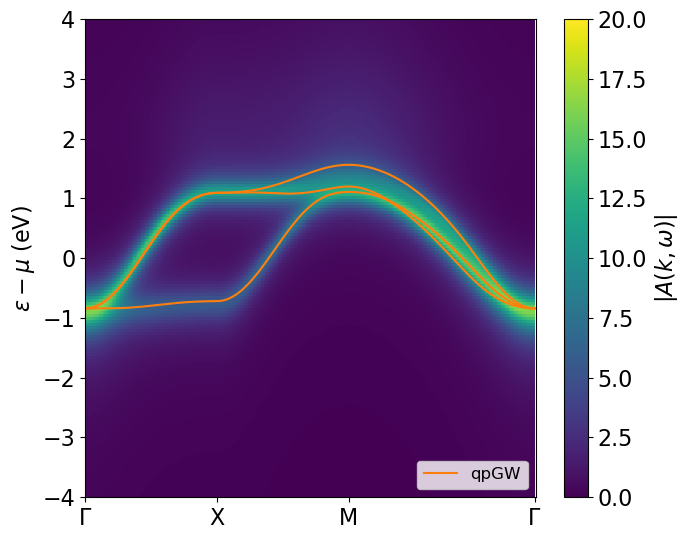

In [ ]:
from coqui.post_proc import spectral_interpolation, band_interpolation

fig, ax = plt.subplots(1, figsize=(7, 5.5), dpi=100)
spectral_plot(ax, coqui_h5="svo.mbpt.h5", iteration=-1, calc_type="mbpt", verbal=False, vmax=20)
band_plot(ax, coqui_h5="svo.mbpt.h5", iteration=-1, verbal=False, 
          color="tab:orange", label="qpGW")
ax.set_ylim(-4, 4)
ax.legend(loc=4, fontsize=12)
plt.tight_layout()
plt.show()

#### 🔹 GW+EDMFT execution

Starting from a GW checkpoint and a correlated subspace $\mathcal{C}$ defined by the MLWFs, a GW+EDMFT calculation is launched by calling the `coqui.dmft.run_gw_edmft` function: 

> ```
> coqui.dmft.run_gw_edmft(h_int: ThcCoulomb, embedding: ModEST.Embedding, params: dict)
> ```

Function inputs:
- `h_int`: `ThcCoulomb` instance containing the lattice Coulomb Hamiltonian used in the GW updates.

- `embedding`: `ModEST.Embedding` instance defining the correlated low-energy subspace $\mathcal{C}$ treated at the impurity level.

- `params`: dictionary containing the GW+EDMFT run settings. The most important entries for this tutorial are:

    - `outdir` (default: `"./"`): output directory for the generated checkpoint files.

    - `prefix` (required): file prefix used for the checkpoint `{prefix}.mbpt.h5`.

    - `niter` (required): number of outer GW+EDMFT iterations to perform.

    - `gw_iter_per_loop` (default: 1): number of GW updates per outer GW+EDMFT iteration. 

    - `edmft_iter_per_loop` (default: 1): number of EDMFT impurity updates per outer GW+EDMFT iteration.

    - `wannier_file` (required): MLWF HDF5 archive that defines the correlated subspace $\mathcal{C}$. 

    - `screen_type` (default: `"gw_edmft"`): screening prescription used to build the lattice irreducible polarization.

    - `edmft["chkpt_h5"]` (optional; default: write impurity data into `{outdir}/{prefix}.mbpt.h5`): redirect the impurity inputs and solver results to a separate HDF5 file. 

    - `edmft["impurity"]` (required): impurity-solver configuration block. See the note below for the most important CT-SEG controls.

> **Note on the impurity solver.** The EDMFT step solves a quantum impurity model with retarded interations. CoQuí drives this via TRIQS/ctseg, a continuous-time hybridization-expansion quantum Monte Carlo solver, which natively supports density–density retarded interactionsd. The CT-SEG controls you will most often touch — all set inside `edmft["impurity"]` — fall into three groups:
>
> - **Monte Carlo statistics** (`n_cycles`, `n_warmup_cycles`, `length_cycle`): total measurement cycles across MPI, warmup cycles for equilibration, and updates between successive measurements. Together they set the statistical error on $\tilde{\Sigma}_{\mathrm{imp}}$ and $\tilde{\Pi}_{\mathrm{imp}}$.
>
> - **High-frequency tail fit** (`perform_tail_fit`, `fit_min_w`, `fit_max_w`, `fit_max_moment`): fit the noisy high-Matsubara tail of $\tilde{\Sigma}_{\mathrm{imp}}$ with an analytic $\mathcal{O}(1/i\omega_n)$ form. The fit is performed in the frequency window [`fit_min_w`, `fit_max_w`] with $\mathcal{O}(1/i\omega_n)$ up to order `fit_max_moment`. The high-frequency part of the self-energy (i.e. $w \ge $`fit_min_w`) is then replaced by the fit function. 
>
> - **Chemical-potential adjustment** (`chemical_potential["tolerance"]` and related sub-controls): controls the inner search for the impurity chemical potential that keeps the impurity occupancy consistent with the projected lattice value at every EDMFT iteration.

  
> **Trouble shooting tip**: 
> 1. If the EDMFT convergence does not get improved after increasing the number of Monte Carlo cycles systematically, you might need to revisit your tail fitting parameters: adjust the frequency window [`fit_min_w`, `fit_max_w`] or the fit order `fit_max_moment`. A poor fitting would lead to inaccurate self-energy, detarioting the convergence accuracy. 
>
> 2. If the chemical-potential tolerance is set too tight with respect to the QMC accuracy, the chemical potential search might fail 

Output:
- `{outdir}/{prefix}.mbpt.h5`: lattice checkpoint containing $G^{\mathbf{k}}$, $W^{\mathbf{q}}$, $\Sigma^{\mathbf{k}}$, $\Pi^{\mathbf{q}}$ and related quantities needed for post-processing and restart of the lattice side of the loop. **By default**, the impurity inputs and solver results are also appended to this file, so a single archive holds the complete state of the calculation.

- `edmft["chkpt_h5"]`: present only when `edmft["chkpt_h5"]` is set; in that case the impurity inputs and solver results are written here instead of being appended to the MBPT archive.

> For complete parameter options, use `help(coqui.dmft.run_gw_edmft)`. A full working setup used in this tutorial is collected in `gw_edmft.py`.

#### 🔹 Example - GW+EDMFT for NiO

For the hands-on demonstration of `run_gw_edmft`, we switch to NiO on a $5\times 5\times 5$ k-mesh. NiO is small enough that a short GW+EDMFT run completes within the wall-clock budget of this notebook, while still being a genuinely correlated transition-metal oxide.

Because the CT-QMC impurity solver dominates the cost of each EDMFT update, we launch the calculation externally with MPI parallelization rather than calling `run_gw_edmft` directly inside the notebook. The full driver script is collected in `gw_edmft.py` (shown below); the cell after that executes it with `mpirun -np 5 python gw_edmft.py > gw_edmft.log` so the CT-QMC sampling is distributed across MPI ranks.

To keep the run short, the CT-QMC controls (`n_cycles`, `n_warmup_cycles`, `length_cycle`) are deliberately undersampled — the resulting $\tilde{\Sigma}_{\mathrm{imp}}$ and $\tilde{\Pi}_{\mathrm{imp}}$ will be noisier than in a production calculation. The goal is to see the driver execute end-to-end and to learn how to navigate the checkpoint files it produces, not to obtain a converged self-consistent solution. A longer, more carefully converged NiO run is loaded in Section 2 for the actual physical analysis.

>```python
># gw_edmft.py
>import triqs.utility.mpi as mpi
>import triqs_modest as modest
>import coqui
>
>coqui_mpi = coqui.MpiHandler()
>coqui.set_verbosity(coqui_mpi, output_level=1)
>
># Define correlated subspace via ModEST
>wan_h5 = "nio_555/mlwf_dp/nio_eg.mlwf.h5"
>obe = modest.make_one_body_elements_gw(wan_h5)
>E1 = modest.make_embedding(obe.C_space)
>
>mf_params = {"prefix": "nio", "outdir": "nio_555/out", "nbnd": 40}
>mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type='qe')
>
>thc_params = {"thresh": 1e-5}
>thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)
>
>gw_edmft_params = {
>  "outdir": "./",
>  "prefix": "nio",
>  "niter": 1,
>  "wannier_file": wan_h5,
>  "screen_type": "rpa",
>  "edmft": {
>    "chkpt_h5": "nio.dmft.h5",
>    "impurity": {
>      "degenerate_blk_thresh": 0.001,
>      "length_cycle": 200,
>      "n_warmup_cycles": 5e4,
>      "n_cycles": 1e6,
>      "perform_tail_fit": True,
>      "fit_max_moment": 9,
>      "fit_min_w": 2.0,
>      "fit_max_w": 10.0,
>      "chemical_potential": {"tolerance": 0.05}
>    }
>  }
>}
>coqui.dmft.run_gw_edmft(thc, E1, params=gw_edmft_params)
>```

In [ ]:
%%bash
mpirun -np 5 python gw_edmft.py > gw_edmft.log

#### 🔹 Reading the EDMFT checkpoint

Once the run completes, the impurity inputs and solver results live in `edmft["chkpt_h5"]` (here `nio.dmft.h5`) and the lattice quantities live in `{outdir}/{prefix}.mbpt.h5`. Inside the impurity archive, the EDMFT data are organized by iteration and by impurity index:

```
nio.dmft.h5
├── dmft/
│   ├── iter0/
│   │   └── impurity_0/
│   │       ├── inputs/        # Gloc(τ), Wloc(τ), 𝒢, 𝒰, Vloc, ...
│   │       └── results/       # Σ_imp, Π_imp, Σ_imp − Σ_DC, Π_imp − Π_DC, ...
│   ├── iter1/...
│   └── ...
└── imaginary_fourier_transform/   # DLR mesh metadata
```

The `imaginary_fourier_transform/` group stores the DLR basis metadata needed to interpret the imaginary-time and Matsubara-frequency quantities under each iteration; it is read automatically when you construct an `IAFT` object (see Tutorial 03 for an introduction).

A quick first pass at the archive — useful for sanity-checking that the file is well-formed and for seeing which iterations are present — is to print its top-level structure directly through `HDFArchive`:

>```python
>from h5 import HDFArchive
>with HDFArchive("nio.dmft.h5", "r") as ar:
>    print(ar)
>```

For postprocessing it is more convenient to use the helper `coqui.dmft.read_impurity_chkpt`, which returns Python dicts for a chosen iteration:

>```python
>coqui.dmft.read_impurity_chkpt(
>    h5_filename: str,
>    iteration: int = -1,
>    read: str = "both",
>) -> Tuple[List[dict], List[dict]]
>```

Function inputs:
- `h5_filename` (required): path to the impurity HDF5 checkpoint file.

- `iteration` (default `-1`): EDMFT iteration to read; `-1` selects the last iteration.

- `read` (default `"both"`): which data to return — `"inputs"`, `"results"`, or `"both"`.

Function output: a list of dicts (one per impurity) when `read` is `"inputs"` or `"results"`, or a tuple `(results_list, inputs_list)` when `read="both"`. The dict for each impurity contains:

- **Inputs** — the data the solver was handed at that iteration: the local Green's function and screened interaction in imaginary time (`Gloc_t`, `Wloc_t`), the fermionic and bosonic Weiss fields (`g_weiss_iw`, `u_weiss_iw`), and the bare local interaction (`Vloc`).

- **Results** — the data the solver produced: the impurity self-energy and polarization on the DLR mesh (`Sigma_iw`, `Pi_iw`) and on a uniform Matsubara grid (`Sigma_iw_data`, `Pi_iw_data`), their double-counting counterparts (`Sigma_iw_dc_data`, `Pi_iw_dc_data`), the impurity Green's function and screened interaction (`G_iw_data`, `W_iw_data`), the static Hartree–Fock parts (`Sigma_infty`, `Sigma_infty_dc`), and the Green's-function block structure (`gf_struct`).

In [67]:
with HDFArchive("nio.dmft.h5", "r") as ar:
    print(ar)

HDFArchive (partial view) with the following content:
  dmft : subgroup
  imaginary_fourier_transform : subgroup


In [83]:
impurity = coqui.dmft.read_impurity_chkpt("nio_coqui_serious/nio.dmft.h5", iteration=30)

# impurity results
print(list(impurity[0][0].keys()))
# impurity inputs
print(list(impurity[1][0].keys()))

['Chi_iw', 'G_iw', 'G_iw_data', 'Pi_iw', 'Pi_iw_data', 'Pi_iw_dc_data', 'Sigma_infty', 'Sigma_infty_dc', 'Sigma_iw', 'Sigma_iw_data', 'Sigma_iw_dc_data', 'W_iw', 'W_iw_data', 'average_order', 'average_sign', 'convergence', 'density', 'gf_struct', 'mu_imp', 'orbital_occupations']
['Gloc_t', 'Vloc', 'Wloc_t', 'delta_iw', 'g_weiss_iw', 'gf_struct', 'h0', 'u_weiss_iw']


#### 🔹 Convergence analysis

The GW+EDMFT cycle has reached its fixed point when the locally projected lattice quantities coincide with their impurity counterparts, $\tilde{G}_{\mathrm{loc}} = \tilde{G}_{\mathrm{imp}}$ and $\tilde{W}_{\mathrm{loc}} = \tilde{W}_{\mathrm{imp}}$. In practice we monitor a small set of indicators iteration by iteration to gauge how the loop is approaching this condition:

- $|\tilde{G}_{\mathrm{loc}} - \tilde{G}_{\mathrm{imp}}|$ and $|\tilde{W}_{\mathrm{loc}} - \tilde{W}_{\mathrm{imp}}|$: the primary self-consistency indicators.

- $|\Delta \tilde{\mathcal{G}}|$ and $|\Delta \tilde{\mathcal{U}}|$: iteration-to-iteration changes of the fermionic and bosonic Weiss fields, useful for diagnosing slow mixing or oscillations.

- $\mu_{\mathrm{imp}}$ and $n_{\mathrm{imp}}$: the impurity chemical potential and total occupation, which should settle as the loop converges.

- $\tilde{\mathcal{U}}(\omega=0)$: the static value of the impurity screened interaction, a quick read on whether the loop is drifting toward a physically reasonable solution.

CoQuí ships a convenience plotter `coqui.dmft.plot_edmft_convergence` that pulls these quantities from an EDMFT checkpoint and writes them to a multi-panel PNG:

>```python
>coqui.dmft.plot_edmft_convergence(
>    dmft_chkpt: str,
>    *,
>    impurity_index: int = 0,
>    check_w: bool = True,
>    figure_name: str = "edmft_convergence",
>) -> str
>```

Function inputs:
- `dmft_chkpt` (required): path to the EDMFT HDF5 checkpoint.

- `impurity_index` (default `0`): which impurity in the embedding to plot. Only relevant when the embedding contains more than one impurity.

- `check_w` (default `True`): include the $|\tilde{W}_{\mathrm{loc}} - \tilde{W}_{\mathrm{imp}}|$ panel. Set to `False` for runs in which the lattice screened interaction is not iterated (e.g. `screen_type="rpa"`, as in the NiO example above).

- `figure_name` (default `"edmft_convergence"`): output filename prefix; the function appends `_imp{impurity_index}.png`.

Function output: the path of the written PNG file.

In [ ]:
dmft_chkpt = "nio_coqui_serious/rpa_screen/nio.dmft.h5"
coqui.dmft.plot_edmft_convergence(dmft_chkpt, check_w=False)

'edmft_convergence_imp0.png'

In [84]:
help(coqui.dmft.plot_edmft_convergence)

Help on function plot_edmft_convergence in module coqui.dmft.plot:

plot_edmft_convergence(dmft_chkpt, *, impurity_index=0, check_w=True, figure_name='edmft_convergence')
    Plot EDMFT convergence diagnostics for a single impurity.
    
    Reads the convergence history from the DMFT checkpoint file and produces a
    multi-panel figure.  The following quantities are plotted when available:
    
    - ``U(w=0)``       – orbital-averaged static local interaction at w=0 (should be constant)
    - ``A(w=0)``       – spectral-weight proxy at the Fermi level (should be constant)
    - ``|Gloc - Gimp|``  – fermionic self-consistency residual (should → 0)
    - ``|dg_weiss|``   – change in fermionic Weiss field between iterations (should → 0)
    - ``|du_weiss|``   – change in bosonic Weiss field between iterations (should → 0)
    - ``|Wloc - Wimp|``  – bosonic self-consistency residual (plotted only when
                            ``check_w=True`` and at least one stored value is valid)
 

### Section 2: Analysis of GW+EDMFT results

In the previous section, we initialized a short GW+EDMFT workflow for SrVO$_3$ and identified where the main lattice and impurity quantities are stored. In this section, we will analyze results from a more converged SrVO$_3$ checkpoint and compare how spectral functions, self-energies, and screened interactions evolve relative to the GW starting point.

#### 🔹 Local spectral functions from impurity Green's function

#### 🔹 Local spectrum of the impurity screened interaction

#### 🔹 Effective interactions for V $t_{2g}$ and its comparison with cRPA

In [24]:
dmft_h5 = "svo.dmft.h5"
iaft = coqui.IAFT.from_coqui_chkpt(dmft_h5)

niter, solver_inputs = 1, []
for it in range(niter):
    inp = coqui.dmft.read_impurity_chkpt(dmft_h5, read="inputs", iteration=it)
    solver_inputs.append(inp[0])

solver_results = []
for it in range(niter):
    res = coqui.dmft.read_impurity_chkpt(dmft_h5, read="results", iteration=it)
    solver_results.append(res[0])

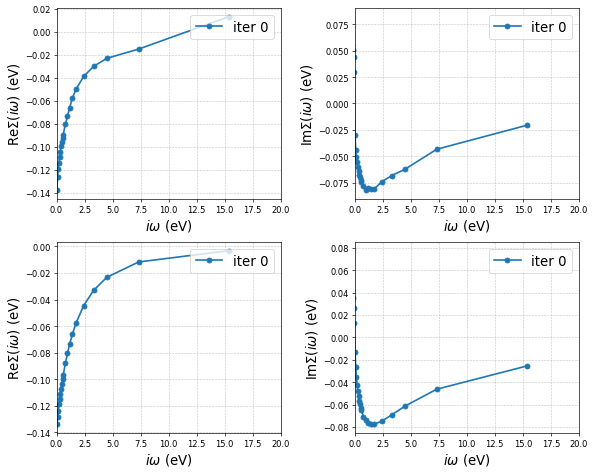

In [25]:
Hartree_eV = 1.0
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(2, 2, figsize=(10,8), dpi=60)
offset = 0
for i in range(offset,len(solver_results), 15):
    ax[0,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[0,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')

xmin, xmax = 0, 20.0
for i in range(2):
    ax[i,0].set_xlim(xmin, xmax)
    ax[i,0].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,0].set_ylabel("Re$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,0].legend(loc=1, ncol=2, fontsize=16)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

for i in range(2):
    ax[i,1].set_xlim(xmin, xmax)
    #ax[i,1].set_ylim(-2.5, 0.0)
    ax[i,1].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,1].set_ylabel("Im$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,1].legend(loc=1, ncol=2, fontsize=16)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
 
plt.tight_layout()
Hartree_eV = 27.211386245988

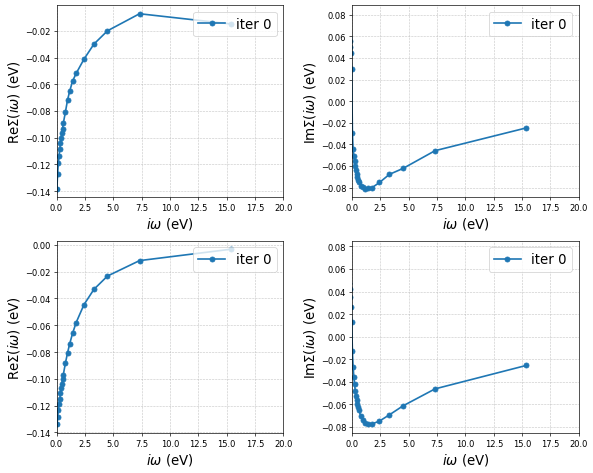

In [21]:
Hartree_eV = 1.0
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(2, 2, figsize=(10,8), dpi=60)
offset = 0
for i in range(offset,len(solver_results), 15):
    ax[0,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[0,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')

xmin, xmax = 0, 20.0
for i in range(2):
    ax[i,0].set_xlim(xmin, xmax)
    ax[i,0].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,0].set_ylabel("Re$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,0].legend(loc=1, ncol=2, fontsize=16)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

for i in range(2):
    ax[i,1].set_xlim(xmin, xmax)
    #ax[i,1].set_ylim(-2.5, 0.0)
    ax[i,1].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,1].set_ylabel("Im$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,1].legend(loc=1, ncol=2, fontsize=16)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
 
plt.tight_layout()
Hartree_eV = 27.211386245988

In [22]:
from coqui.dmft.ctseg.ctseg_utils import tail_fit, fill_dlr_imfreq_gf
from triqs.gf import *
from triqs.plot.mpl_interface import oplot

def sigma_tail_fit(Sigma_dlr_iw_raw, gf_struct, Sigma_infty=None, 
                   fit_min_w=1.8, fit_max_w=4.5, fit_max_moment=12):
    # get raw self-energy on a uniform Matsubara mesh 
    wmax, eps = Sigma_dlr_iw_raw.mesh.w_max, Sigma_dlr_iw_raw.mesh.eps
    Sigma_iw_raw = make_gf_imfreq(make_gf_dlr(Sigma_dlr_iw_raw), n_iw = 1000)

    # get analytic moment 
    if Sigma_infty is not None:
        Sigma_moments = {}
        for i, struct in enumerate(gf_struct):
            Sigma_moments[struct[0]] = np.array([Sigma_infty[i]], dtype=complex)
    else:
        Sigma_moments = None

    Sigma_iw_fit = tail_fit(
        Sigma_iw_raw, 
        fit_min_w=fit_min_w, fit_max_w=fit_max_w, fit_max_moment=fit_max_moment, fit_known_moments=Sigma_moments
    )
    Sigma_iw_fit = fill_dlr_imfreq_gf(Sigma_iw_fit, wmax, eps)

    return Sigma_iw_fit

Tail fit for Σ(iω):
  fit window : ω = [1.9792, 9.9588] a.u.
  max moment : 20
  known moments provided : yes



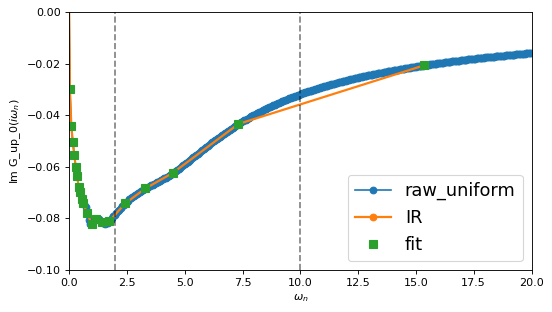

In [26]:
wmin, wmax, order = 2.0, 10.0, 20
Sigma_iw_fit = sigma_tail_fit(
    solver_results[0]['Sigma_iw'], solver_results[0]['gf_struct'], solver_results[0]['Sigma_infty'], 
    wmin, wmax, order
)
Sigma_iw_raw = make_gf_imfreq(make_gf_dlr(solver_results[0]['Sigma_iw']), n_iw = 1000)

fig, ax = plt.subplots(1, figsize=(7,4), dpi=80)
ax.oplot(Sigma_iw_raw['up_0'].imag, marker='o', label="raw_uniform")
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta
ax.plot(iw_mesh_f, solver_results[0]['Sigma_iw_data'][0][:,0,0].imag, 
        linestyle='-', marker='o', markersize=6, linewidth=2, label=f'IR')
ax.oplot(Sigma_iw_fit['up_0'].imag, marker='s', linestyle='--', markersize=8, label="fit")
ax.axvline(x=wmin, color='black', alpha=0.5, linestyle='--')
ax.axvline(x=wmax, color='black', alpha=0.5, linestyle='--')
ax.set_xlim(0, 20.0)
ax.set_ylim(-0.1, 0.00)
ax.legend(fontsize=16)
plt.tight_layout()

Tail fit for Σ(iω):
  fit window : ω = [1.9792, 9.9588] a.u.
  max moment : 20
  known moments provided : yes


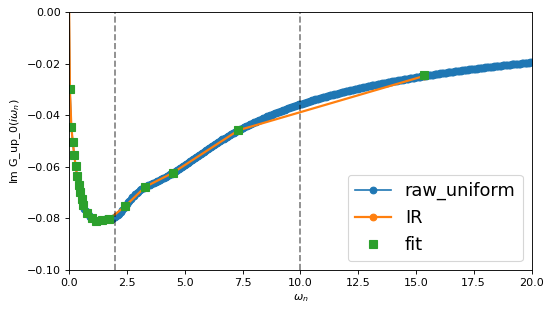

In [23]:
wmin, wmax, order = 2.0, 10.0, 20
Sigma_iw_fit = sigma_tail_fit(
    solver_results[0]['Sigma_iw'], solver_results[0]['gf_struct'], solver_results[0]['Sigma_infty'], 
    wmin, wmax, order
)
Sigma_iw_raw = make_gf_imfreq(make_gf_dlr(solver_results[0]['Sigma_iw']), n_iw = 1000)

fig, ax = plt.subplots(1, figsize=(7,4), dpi=80)
ax.oplot(Sigma_iw_raw['up_0'].imag, marker='o', label="raw_uniform")
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta
ax.plot(iw_mesh_f, solver_results[0]['Sigma_iw_data'][0][:,0,0].imag, 
        linestyle='-', marker='o', markersize=6, linewidth=2, label=f'IR')
ax.oplot(Sigma_iw_fit['up_0'].imag, marker='s', linestyle='--', markersize=8, label="fit")
ax.axvline(x=wmin, color='black', alpha=0.5, linestyle='--')
ax.axvline(x=wmax, color='black', alpha=0.5, linestyle='--')
ax.set_xlim(0, 20.0)
ax.set_ylim(-0.1, 0.00)
ax.legend(fontsize=16)
plt.tight_layout()

Tail fit for Σ(iω):
  fit window : ω = [1.9792, 9.9588] a.u.
  max moment : 20
  known moments provided : yes



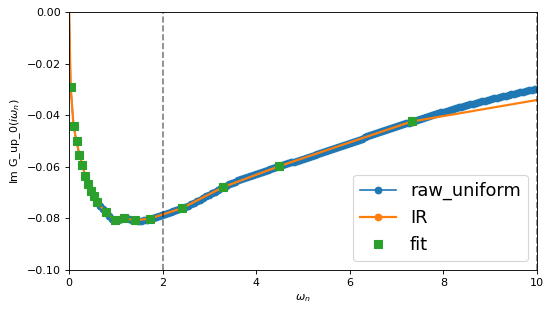

In [8]:
wmin, wmax, order = 2.0, 10.0, 20
Sigma_iw_fit = sigma_tail_fit(
    solver_results[0]['Sigma_iw'], solver_results[0]['gf_struct'], solver_results[0]['Sigma_infty'], 
    wmin, wmax, order
)
Sigma_iw_raw = make_gf_imfreq(make_gf_dlr(solver_results[0]['Sigma_iw']), n_iw = 1000)

fig, ax = plt.subplots(1, figsize=(7,4), dpi=80)
ax.oplot(Sigma_iw_raw['up_0'].imag, marker='o', label="raw_uniform")
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta
ax.plot(iw_mesh_f, solver_results[0]['Sigma_iw_data'][0][:,0,0].imag, 
        linestyle='-', marker='o', markersize=6, linewidth=2, label=f'IR')
ax.oplot(Sigma_iw_fit['up_0'].imag, marker='s', linestyle='--', markersize=8, label="fit")
ax.axvline(x=wmin, color='black', alpha=0.5, linestyle='--')
ax.axvline(x=wmax, color='black', alpha=0.5, linestyle='--')
ax.set_xlim(0, 10.0)
ax.set_ylim(-0.1, 0.00)
ax.legend(fontsize=16)
plt.tight_layout()

#### 🔹 Local correlation functions

[TODO Check the dmft checkpoint file and visualize the local Green's function and local screened interaction $G_{\mathrm{loc}}$ and $W_{\mathrm{loc}}$.]

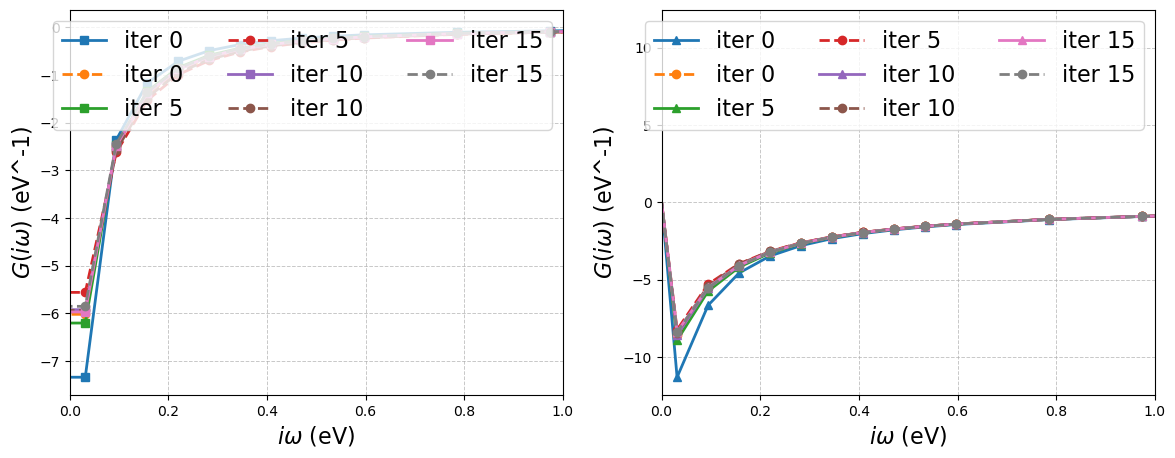

In [5]:
Hartree_eV = 1.0
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, 2, figsize=(14,5), dpi=100)
offset = 0
for i in range(offset, len(solver_inputs),5):
    G_iw_t2g = iaft.tau_to_w(solver_inputs[i]['Gloc_t'][0], 'f')

    ax[0].plot(iw_mesh_f, G_iw_t2g[:,0,0].real/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[0].plot(iw_mesh_f, solver_results[i]['G_iw_data'][0][:,0,0].real/Hartree_eV, 
            linestyle='--', marker='o', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_f, G_iw_t2g[:,0,0].imag/Hartree_eV, 
            linestyle='-', marker='^', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_f, solver_results[i]['G_iw_data'][0][:,0,0].imag/Hartree_eV, 
            linestyle='--', marker='o', linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i].set_xlim(0, 1.0)
    ax[i].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i].set_ylabel("$G(i\omega)$ (eV^-1)", fontsize=16)
    ax[i].legend(ncol=3, loc=1, fontsize=16)
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
Hartree_eV = 27.211386245988

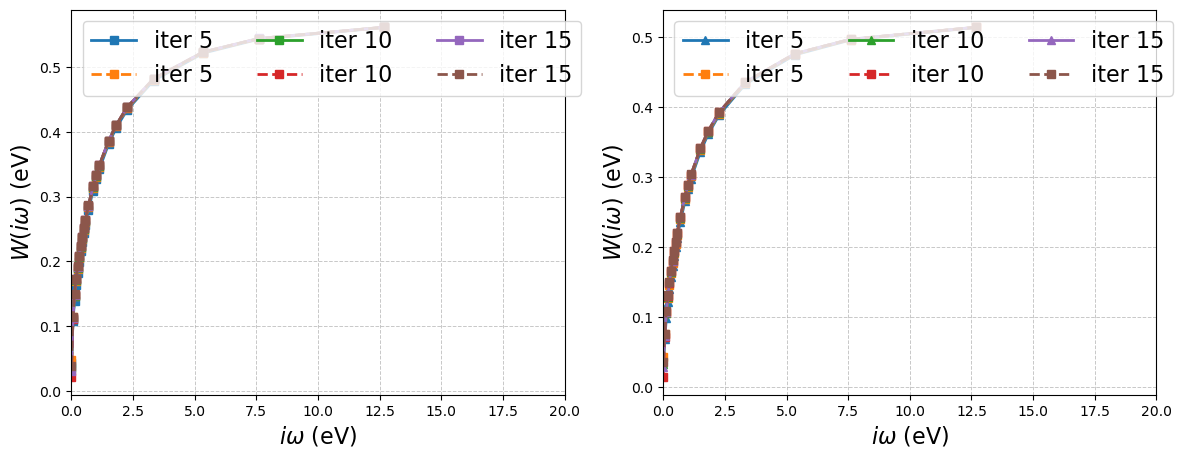

In [6]:
Hartree_eV = 1.0
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, 2, figsize=(14,5), dpi=100)
offset = 5
for i in range(offset, len(solver_inputs),5):
    W_iw = iaft.tau_to_w_phsym(solver_inputs[i]['Wloc_t'], 'boson')
    ax[0].plot(iw_mesh_b, (W_iw[:,0,0,0,0].real+solver_inputs[i]['Vloc'][0,0,0,0].real)*Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[0].plot(iw_mesh_b, (solver_results[i]['W_iw_data'][0][:,0,0].real+solver_inputs[i]['Vloc'][0,0,0,0].real)*Hartree_eV, 
            linestyle='--', marker='s', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_b, (W_iw[:,0,0,1,1].real+solver_inputs[i]['Vloc'][0,0,1,1].real)*Hartree_eV, 
            linestyle='-', marker='^', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_b, (solver_results[i]['W_iw_data'][0][:,0,1].real+solver_inputs[i]['Vloc'][0,0,1,1].real)*Hartree_eV, 
            linestyle='--', marker='s', linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i].set_xlim(0, 20)
    #ax[i].set_ylim(-1, 10)
    ax[i].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i].set_ylabel("$W(i\omega)$ (eV)", fontsize=16)
    ax[i].legend(ncol=3, loc=2, fontsize=16)
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

Hartree_eV = 27.211386245988

#### 🔹 Impurity problem - Weiss fields 
[TODO Check the dmft checkpoint file and visualize the impurity Weiss fields $\mathcal{G}$ and $\mathcal{U}$.]

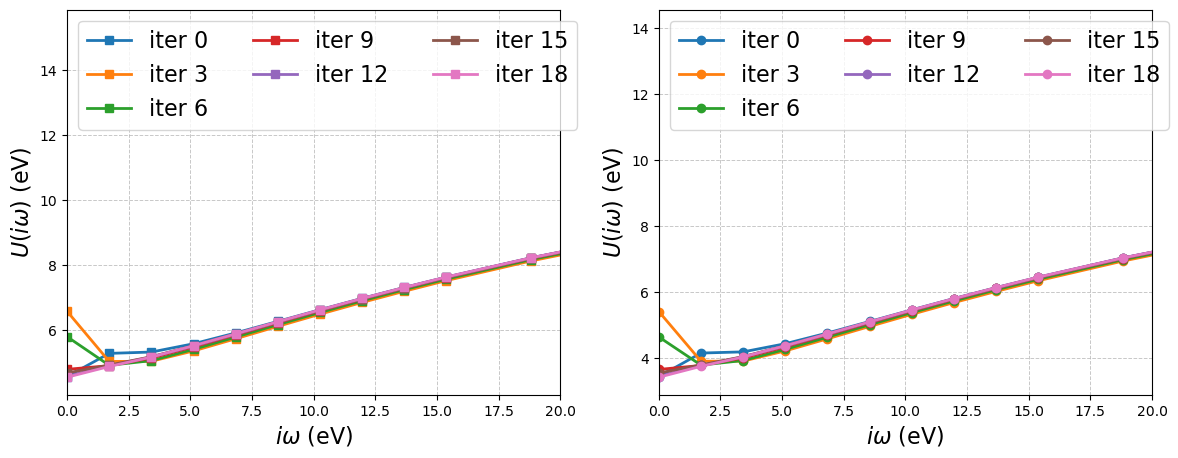

In [9]:
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, 2, figsize=(14,5), dpi=100)
offset = 0
for i in range(offset,len(solver_inputs),3):
    ax[0].plot(iw_mesh_b, (solver_inputs[i]['u_weiss_iw'][:,0,0,0,0].real+solver_inputs[i]['Vloc'][0,0,0,0].real)*Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_b, (solver_inputs[i]['u_weiss_iw'][:,0,0,1,1].real+solver_inputs[i]['Vloc'][0,0,1,1].real)*Hartree_eV, 
            linestyle='-', marker='o', linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i].set_xlim(0, 20)
    #ax[i].set_ylim(2, 18)
    ax[i].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i].set_ylabel("$U(i\omega)$ (eV)", fontsize=16)
    ax[i].legend(ncol=3, loc=2, fontsize=16)
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

#### 🔹 Impurity solution
[TODO Check the dmft checkpoint file and visualize the impurity solutions $\Sigma_{\mathrm{imp}}$ and $\Pi_{\mathrm{imp}}$, and compare to the double counting solution.]

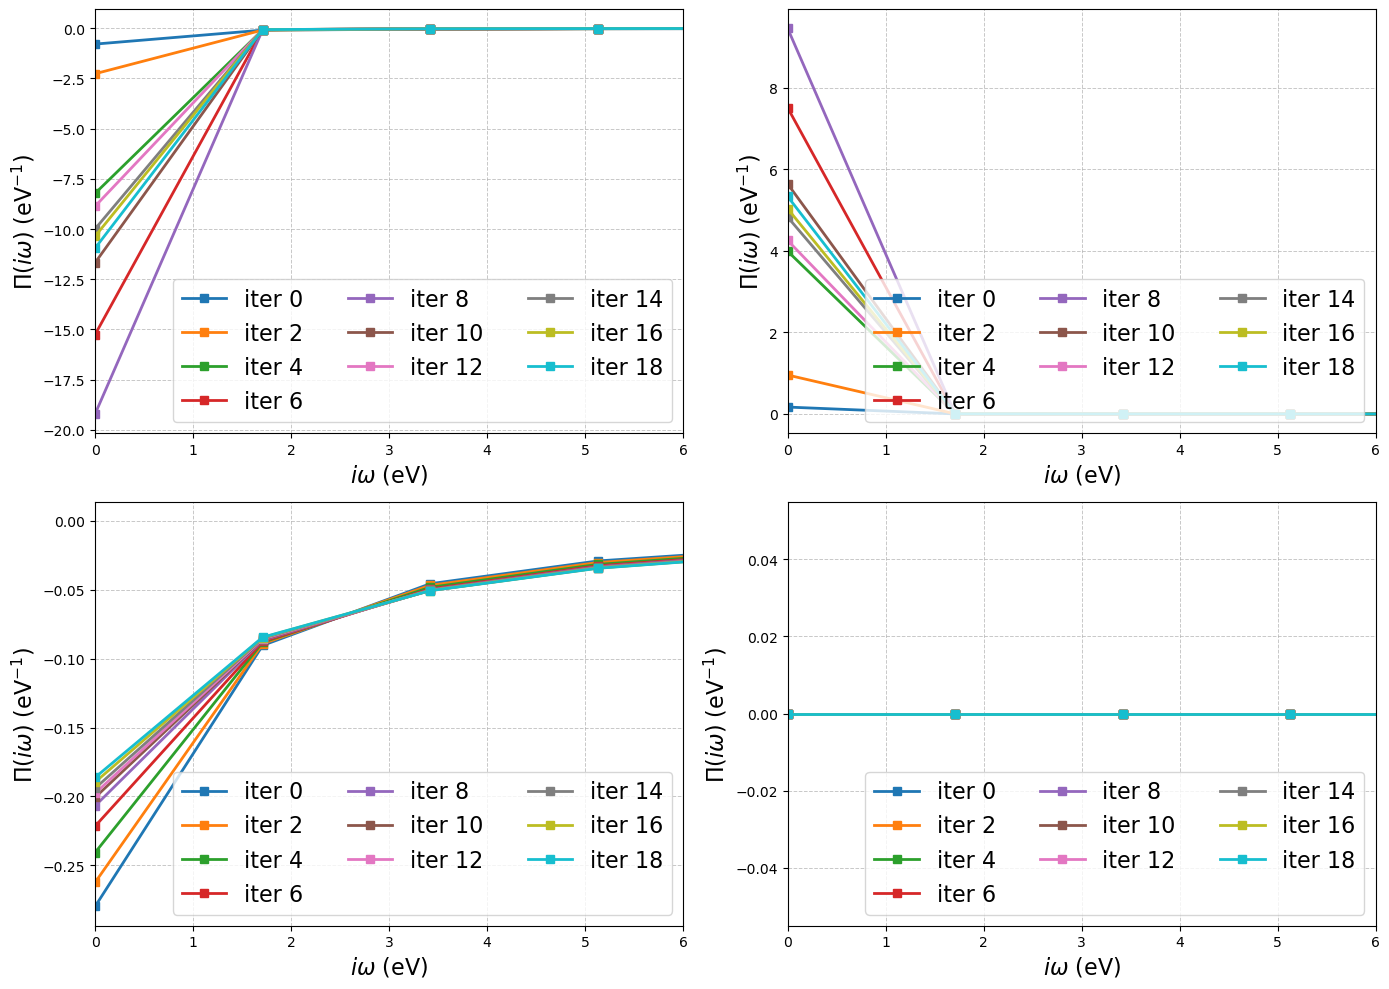

In [11]:
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(2, 2, figsize=(14,10), dpi=100)

offset = 0
for i in range(offset,len(solver_results), 2):
    ax[0,0].plot(iw_mesh_b, (solver_results[i]['Pi_iw_data'][0][:,0,0].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[0,1].plot(iw_mesh_b, (solver_results[i]['Pi_iw_data'][0][:,0,1].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1,0].plot(iw_mesh_b, (solver_results[i]['Pi_iw_dc_data'][0][:,0,0].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1,1].plot(iw_mesh_b, (solver_results[i]['Pi_iw_dc_data'][0][:,0,1].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')

for ij in range(4):
    i = ij//2
    j = ij%2
    ax[i,j].set_xlim(0, 6)
    ax[i,j].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,j].set_ylabel("$\Pi(i\omega)$ (eV$^{-1}$)", fontsize=16)
    ax[i,j].legend(ncol=3, loc=4, fontsize=16)
    ax[i,j].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,j].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

plt.tight_layout()

In [12]:
for i in range(len(solver_results)):
    vhf_dc = solver_results[i]['Sigma_infty_dc'][0][0,0]
    vhf_imp = solver_results[i]['Sigma_infty'][0][0,0]
    print(f"Vhf imp = {vhf_imp.real}, Vhf dc = {vhf_dc.real}, diff = {vhf_imp.real-vhf_dc.real}")

Vhf imp = 0.0417279582065122, Vhf dc = 0.04224546163261174, diff = -0.0005175034260995401
Vhf imp = 0.05715240757947651, Vhf dc = 0.05584725349526384, diff = 0.0013051540842126674
Vhf imp = 0.0790108791887821, Vhf dc = 0.0804613747214037, diff = -0.0014504955326216096
Vhf imp = 0.09396336113306729, Vhf dc = 0.09384374444683995, diff = 0.00011961668622734178
Vhf imp = 0.10928004889812731, Vhf dc = 0.10825369394756562, diff = 0.001026354950561692
Vhf imp = 0.11525025595907783, Vhf dc = 0.11730393014722887, diff = -0.0020536741881510417
Vhf imp = 0.11072571264346329, Vhf dc = 0.10998530021937146, diff = 0.000740412424091827
Vhf imp = 0.10696108695193879, Vhf dc = 0.10420321675039967, diff = 0.0027578702015391143
Vhf imp = 0.0982015509250097, Vhf dc = 0.09830929746973349, diff = -0.00010774654472378575
Vhf imp = 0.0840298852934942, Vhf dc = 0.08422366806305492, diff = -0.00019378276956072416
Vhf imp = 0.0728424797883854, Vhf dc = 0.07411671929526875, diff = -0.0012742395068833512
Vhf imp =

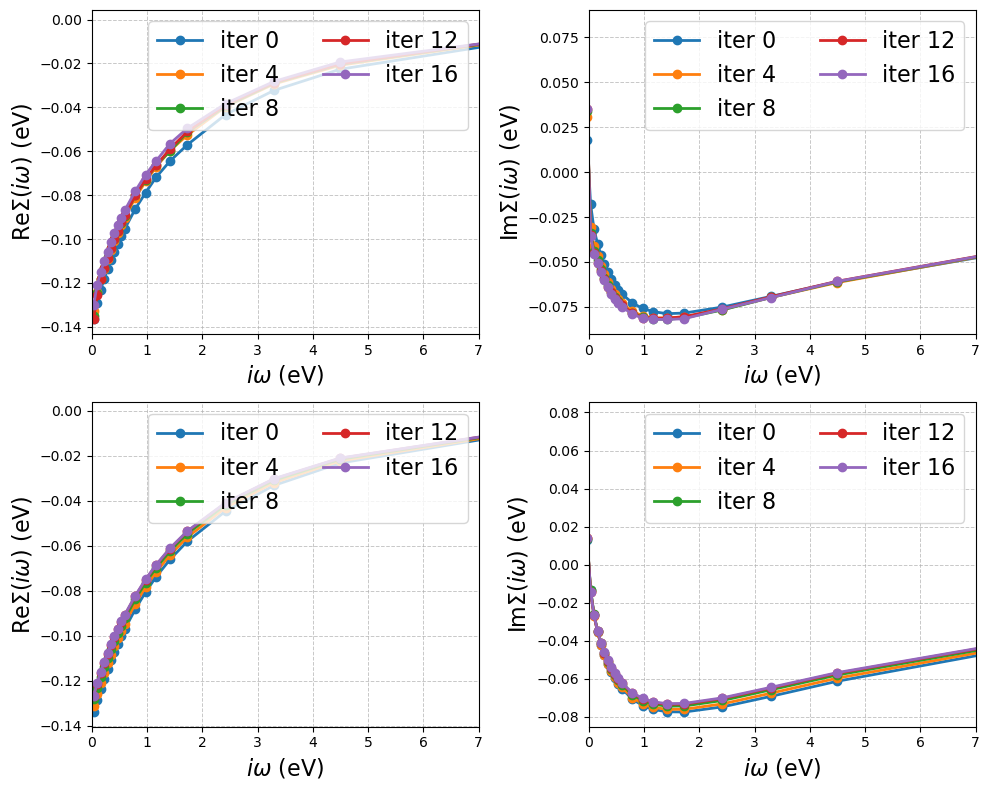

In [13]:
Hartree_eV = 1.0
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(2, 2, figsize=(10,8), dpi=100)
offset = 0
for i in range(offset,len(solver_results), 4):
    ax[0,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[0,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i,0].set_xlim(0, 7.0)
    ax[i,0].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,0].set_ylabel("Re$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,0].legend(loc=1, ncol=2, fontsize=16)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

for i in range(2):
    ax[i,1].set_xlim(0, 7.0)
    #ax[i,1].set_ylim(-2.5, 0.0)
    ax[i,1].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,1].set_ylabel("Im$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,1].legend(loc=1, ncol=2, fontsize=16)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
 
plt.tight_layout()
Hartree_eV = 27.211386245988